(GLM-ZeroSumNormal)=
# Sum-to-Zero Constraints with ZeroSumNormal

:::{post} February, 2026
:tags: sum-to-zero, identifiability, categorical regression, generalized linear model
:category: intermediate
:author: Claude (based on original work by Benjamin T. Vincent and Adrian Seyboldt)
:::

When modeling categorical predictors in regression, we often encounter **identifiability problems** due to linear dependencies in the design matrix. This notebook explains:

1. **Why** sum-to-zero constraints are needed (identifiability)
2. **How** design matrices create linear dependence
3. **What** contrast coding schemes do and their expected values
4. **How** `pm.ZeroSumNormal` solves these problems elegantly

The `ZeroSumNormal` distribution was developed by [Adrian Seyboldt](https://github.com/aseyboldt) at [PyMC Labs](https://www.pymc-labs.io/) and is now available natively in PyMC (since v4.2.2).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from scipy import stats

WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")
plt.rcParams['figure.dpi'] = 150

RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

## The Identifiability Problem

### Why Sum-to-Zero Constraints Matter

Consider a simple scenario: we want to compare the means of $K=3$ groups. We could write a model as:

$$
y_i \sim \text{Normal}(\mu_0 + \mu_{\text{group}[i]}, \sigma)
$$

where $\mu_0$ is the overall mean and $\mu_{\text{group}[i]}$ is the group-specific effect for observation $i$.

The problem is that this parameterization is **not identifiable**. If we have:
- $\mu_0 = 5$ and group effects $(\mu_1, \mu_2, \mu_3) = (-2, 0, 2)$

We get the same predictions as:
- $\mu_0 = 7$ and group effects $(\mu_1, \mu_2, \mu_3) = (-4, -2, 0)$

This happens because we can always shift all group effects by a constant $c$ while subtracting $c$ from the intercept.

### Linear Dependence in Design Matrices

Let's see this problem mathematically. If we use **dummy coding** (one-hot encoding) for $K$ groups, our design matrix looks like:

In [3]:
# Example: 9 observations from 3 groups
groups = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])

# One-hot encoding (dummy coding)
n_groups = 3
X_dummy = np.zeros((len(groups), n_groups))
for i, g in enumerate(groups):
    X_dummy[i, g] = 1

# Add intercept column
X_full = np.column_stack([np.ones(len(groups)), X_dummy])

print("Design matrix with intercept + all group dummies:")
print(X_full)
print(f"\nMatrix rank: {np.linalg.matrix_rank(X_full)} (should be {X_full.shape[1]} for full rank)")
print(f"\nNotice: Column 0 (intercept) = Column 1 + Column 2 + Column 3")
print(f"Sum of group columns: {X_dummy.sum(axis=1)}")

Design matrix with intercept + all group dummies:
[[1. 1. 0. 0.]
 [1. 1. 0. 0.]
 [1. 1. 0. 0.]
 [1. 0. 1. 0.]
 [1. 0. 1. 0.]
 [1. 0. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]]

Matrix rank: 3 (should be 4 for full rank)

Notice: Column 0 (intercept) = Column 1 + Column 2 + Column 3
Sum of group columns: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


The design matrix is **rank deficient** because the group indicator columns sum to the intercept column. This means we cannot uniquely estimate all parameters.

### Traditional Solutions

There are several common approaches to resolve this:

1. **Reference coding (treatment contrasts)**: Drop one category as the reference level
2. **Sum-to-zero coding**: Constrain the group effects to sum to zero
3. **Effects coding**: Similar to sum-to-zero but with different parameterization

Each approach has trade-offs in interpretation.

## Contrast Coding Schemes

### Reference (Treatment) Coding

The most common approach drops one category. The intercept becomes the mean of the reference group, and other coefficients represent differences from that reference.

**Problem**: The choice of reference is arbitrary, and the intercept's interpretation depends on this choice.

In [4]:
# Reference coding: drop first group
X_reference = X_dummy[:, 1:]  # Drop first column
X_reference_full = np.column_stack([np.ones(len(groups)), X_reference])

print("Reference coding design matrix:")
print(X_reference_full)
print(f"\nMatrix rank: {np.linalg.matrix_rank(X_reference_full)} (full rank!)")
print("\nInterpretation:")
print("  - Intercept = mean of group 0 (reference)")
print("  - beta_1 = (mean of group 1) - (mean of group 0)")
print("  - beta_2 = (mean of group 2) - (mean of group 0)")

Reference coding design matrix:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]

Matrix rank: 3 (full rank!)

Interpretation:
  - Intercept = mean of group 0 (reference)
  - beta_1 = (mean of group 1) - (mean of group 0)
  - beta_2 = (mean of group 2) - (mean of group 0)


### Sum-to-Zero Coding

A more symmetric approach constrains the group effects to sum to zero:

$$\sum_{k=1}^{K} \beta_k = 0$$

This means:
- The intercept represents the **grand mean** across all groups
- Each $\beta_k$ represents the **deviation** of group $k$ from the grand mean

The expected value for each group is:
$$E[y | \text{group}=k] = \mu_0 + \beta_k$$

where $\mu_0$ is the grand mean.

In [5]:
# Sum-to-zero contrast matrix
# For K groups, we need K-1 contrasts
# Last group gets coded as -1 for all contrasts

def sum_to_zero_contrast(K):
    """Create sum-to-zero contrast matrix for K groups."""
    C = np.eye(K-1)
    C = np.vstack([C, -np.ones(K-1)])
    return C

C = sum_to_zero_contrast(3)
print("Sum-to-zero contrast matrix:")
print(C)
print(f"\nColumn sums: {C.sum(axis=0)} (all zero!)")

# Apply contrast to our data
X_sumzero = np.zeros((len(groups), n_groups - 1))
for i, g in enumerate(groups):
    X_sumzero[i, :] = C[g, :]

X_sumzero_full = np.column_stack([np.ones(len(groups)), X_sumzero])
print("\nSum-to-zero design matrix:")
print(X_sumzero_full)
print(f"\nMatrix rank: {np.linalg.matrix_rank(X_sumzero_full)} (full rank!)")

Sum-to-zero contrast matrix:
[[ 1.  0.]
 [ 0.  1.]
 [-1. -1.]]

Column sums: [0. 0.] (all zero!)

Sum-to-zero design matrix:
[[ 1.  1.  0.]
 [ 1.  1.  0.]
 [ 1.  1.  0.]
 [ 1.  0.  1.]
 [ 1.  0.  1.]
 [ 1.  0.  1.]
 [ 1. -1. -1.]
 [ 1. -1. -1.]
 [ 1. -1. -1.]]

Matrix rank: 3 (full rank!)


### The Challenge with Manual Sum-to-Zero Constraints

While we can encode sum-to-zero constraints in the design matrix, this approach has drawbacks:

1. **Asymmetry**: The last group is treated differently (coded as -1)
2. **Difficult priors**: How do we set priors on $\beta_1, \beta_2$ knowing they're constrained?
3. **Interpretation**: We must back-calculate the effect for the last group

This is where `ZeroSumNormal` provides an elegant solution.

## The ZeroSumNormal Distribution

### Mathematical Foundation

`ZeroSumNormal` is a multivariate normal distribution with the constraint that samples sum to zero. Mathematically:

$$
\text{ZeroSumNormal}(\sigma) = \mathcal{N}\left(0, \sigma^2 \left(I_K - \frac{1}{K}J_K\right)\right)
$$

where:
- $I_K$ is the $K \times K$ identity matrix
- $J_K$ is the $K \times K$ matrix of all ones
- The term $(I_K - \frac{1}{K}J_K)$ is the **centering matrix**

This covariance structure ensures:
1. Each component has variance $\sigma^2 \frac{K-1}{K}$
2. Components are negatively correlated with covariance $-\sigma^2/K$
3. **The sum is exactly zero** (with probability 1)

In [6]:
# Demonstrate ZeroSumNormal properties
K = 4  # number of groups
sigma = 2.0

# Draw samples from ZeroSumNormal
with pm.Model() as demo_model:
    beta = pm.ZeroSumNormal("beta", sigma=sigma, shape=K)
    prior_samples = pm.draw(beta, draws=10000, random_seed=RANDOM_SEED)

print(f"Shape of samples: {prior_samples.shape}")
print(f"Sum of each sample (should be ~0): mean={prior_samples.sum(axis=1).mean():.2e}, std={prior_samples.sum(axis=1).std():.2e}")
print(f"\nSample means: {prior_samples.mean(axis=0)}")
print(f"Sample variances: {prior_samples.var(axis=0)}")
print(f"Expected variance: sigma^2 * (K-1)/K = {sigma**2 * (K-1)/K:.4f}")

Shape of samples: (10000, 4)
Sum of each sample (should be ~0): mean=2.89e-18, std=3.69e-16

Sample means: [ 0.00893064  0.01457198 -0.01071909 -0.01278352]
Sample variances: [2.98001726 3.02950718 3.00198155 2.97644479]
Expected variance: sigma^2 * (K-1)/K = 3.0000


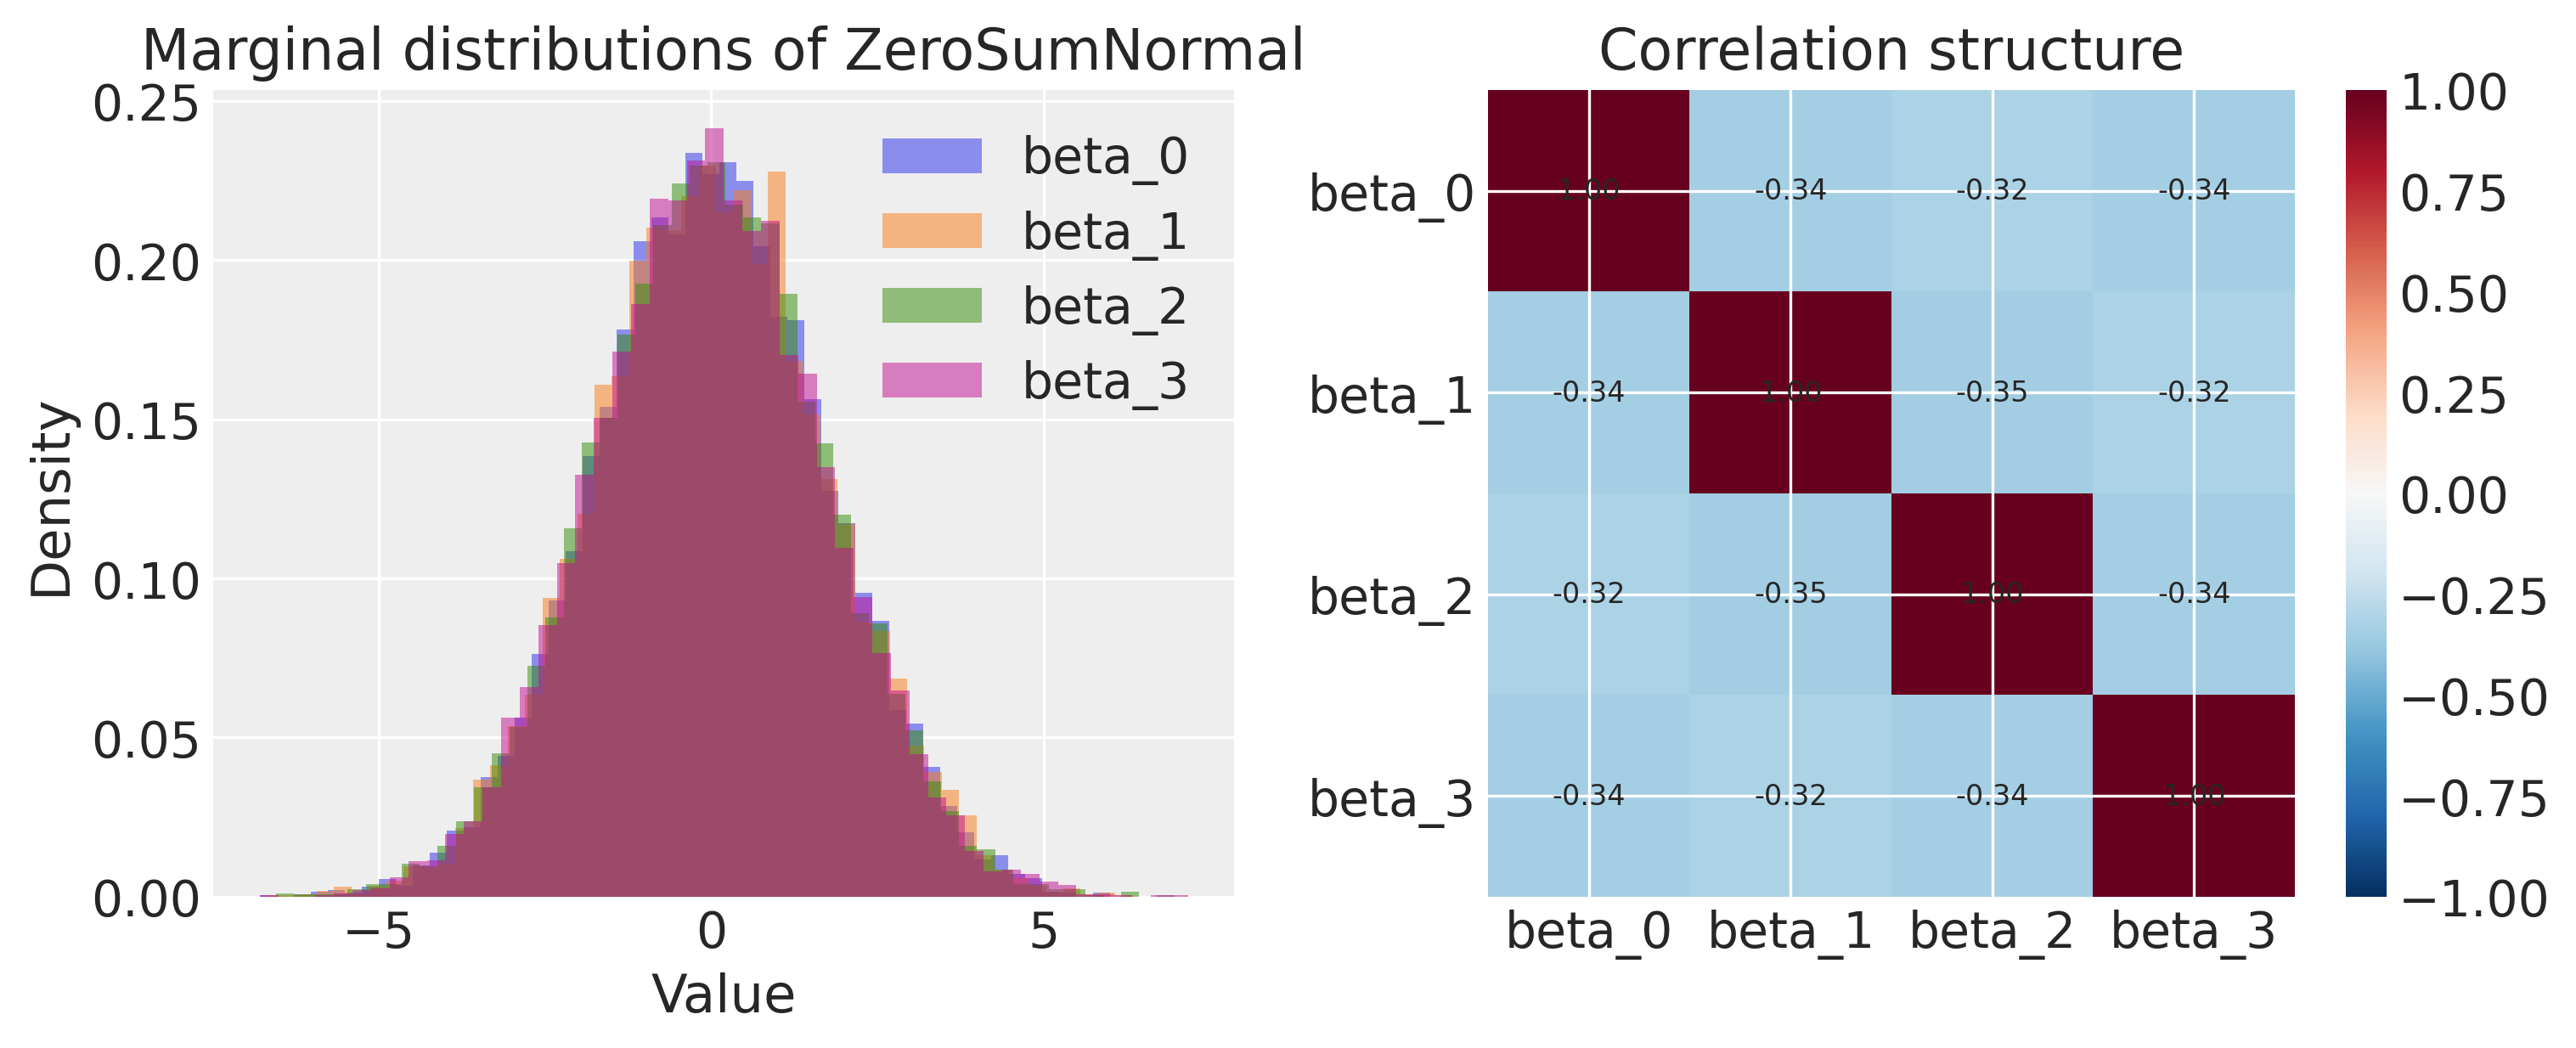

In [7]:
# Visualize the prior
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

# Left: Marginal distributions
for i in range(K):
    axes[0].hist(prior_samples[:, i], bins=50, alpha=0.5, label=f"beta_{i}", density=True)
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].set_title("Marginal distributions of ZeroSumNormal")
axes[0].legend()

# Right: Correlation structure
corr = np.corrcoef(prior_samples.T)
im = axes[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(K))
axes[1].set_yticks(range(K))
axes[1].set_xticklabels([f"beta_{i}" for i in range(K)])
axes[1].set_yticklabels([f"beta_{i}" for i in range(K)])
axes[1].set_title("Correlation structure")
fig.colorbar(im, ax=axes[1])

# Add correlation values
for i in range(K):
    for j in range(K):
        axes[1].text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)

### Benefits of ZeroSumNormal

Compared to manual sum-to-zero coding:

1. **Symmetric parameterization**: All groups are treated equally
2. **Intuitive priors**: The $\sigma$ parameter directly controls the scale of group deviations
3. **Direct interpretation**: Each $\beta_k$ is directly the deviation from the grand mean
4. **Computational efficiency**: Uses a clever reparameterization for efficient sampling

## Practical Example: Comparing Group Means

Let's apply `ZeroSumNormal` to a concrete problem: comparing the effectiveness of different treatments.

In [8]:
# Simulate data
n_per_group = 30
n_groups = 4
group_names = ["Control", "Treatment A", "Treatment B", "Treatment C"]

# True parameters
true_grand_mean = 50.0
true_deviations = np.array([-5.0, 2.0, 8.0, -5.0])  # Must sum to zero!
true_sigma = 5.0

print(f"True grand mean: {true_grand_mean}")
print(f"True deviations: {true_deviations} (sum = {true_deviations.sum()})")
print(f"True group means: {true_grand_mean + true_deviations}")

# Generate data
groups = np.repeat(np.arange(n_groups), n_per_group)
y = rng.normal(true_grand_mean + true_deviations[groups], true_sigma)

# Create DataFrame
df = pd.DataFrame({
    "group": [group_names[g] for g in groups],
    "group_idx": groups,
    "y": y
})

df.head()

True grand mean: 50.0
True deviations: [-5.  2.  8. -5.] (sum = 0.0)
True group means: [45. 52. 58. 45.]


,group,group_idx,y
0,Control,0,43.886789
1,Control,0,51.628294
2,Control,0,42.145150
3,Control,0,48.341246
4,Control,0,50.726905


/tmp/ipykernel_1211/1883129539.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


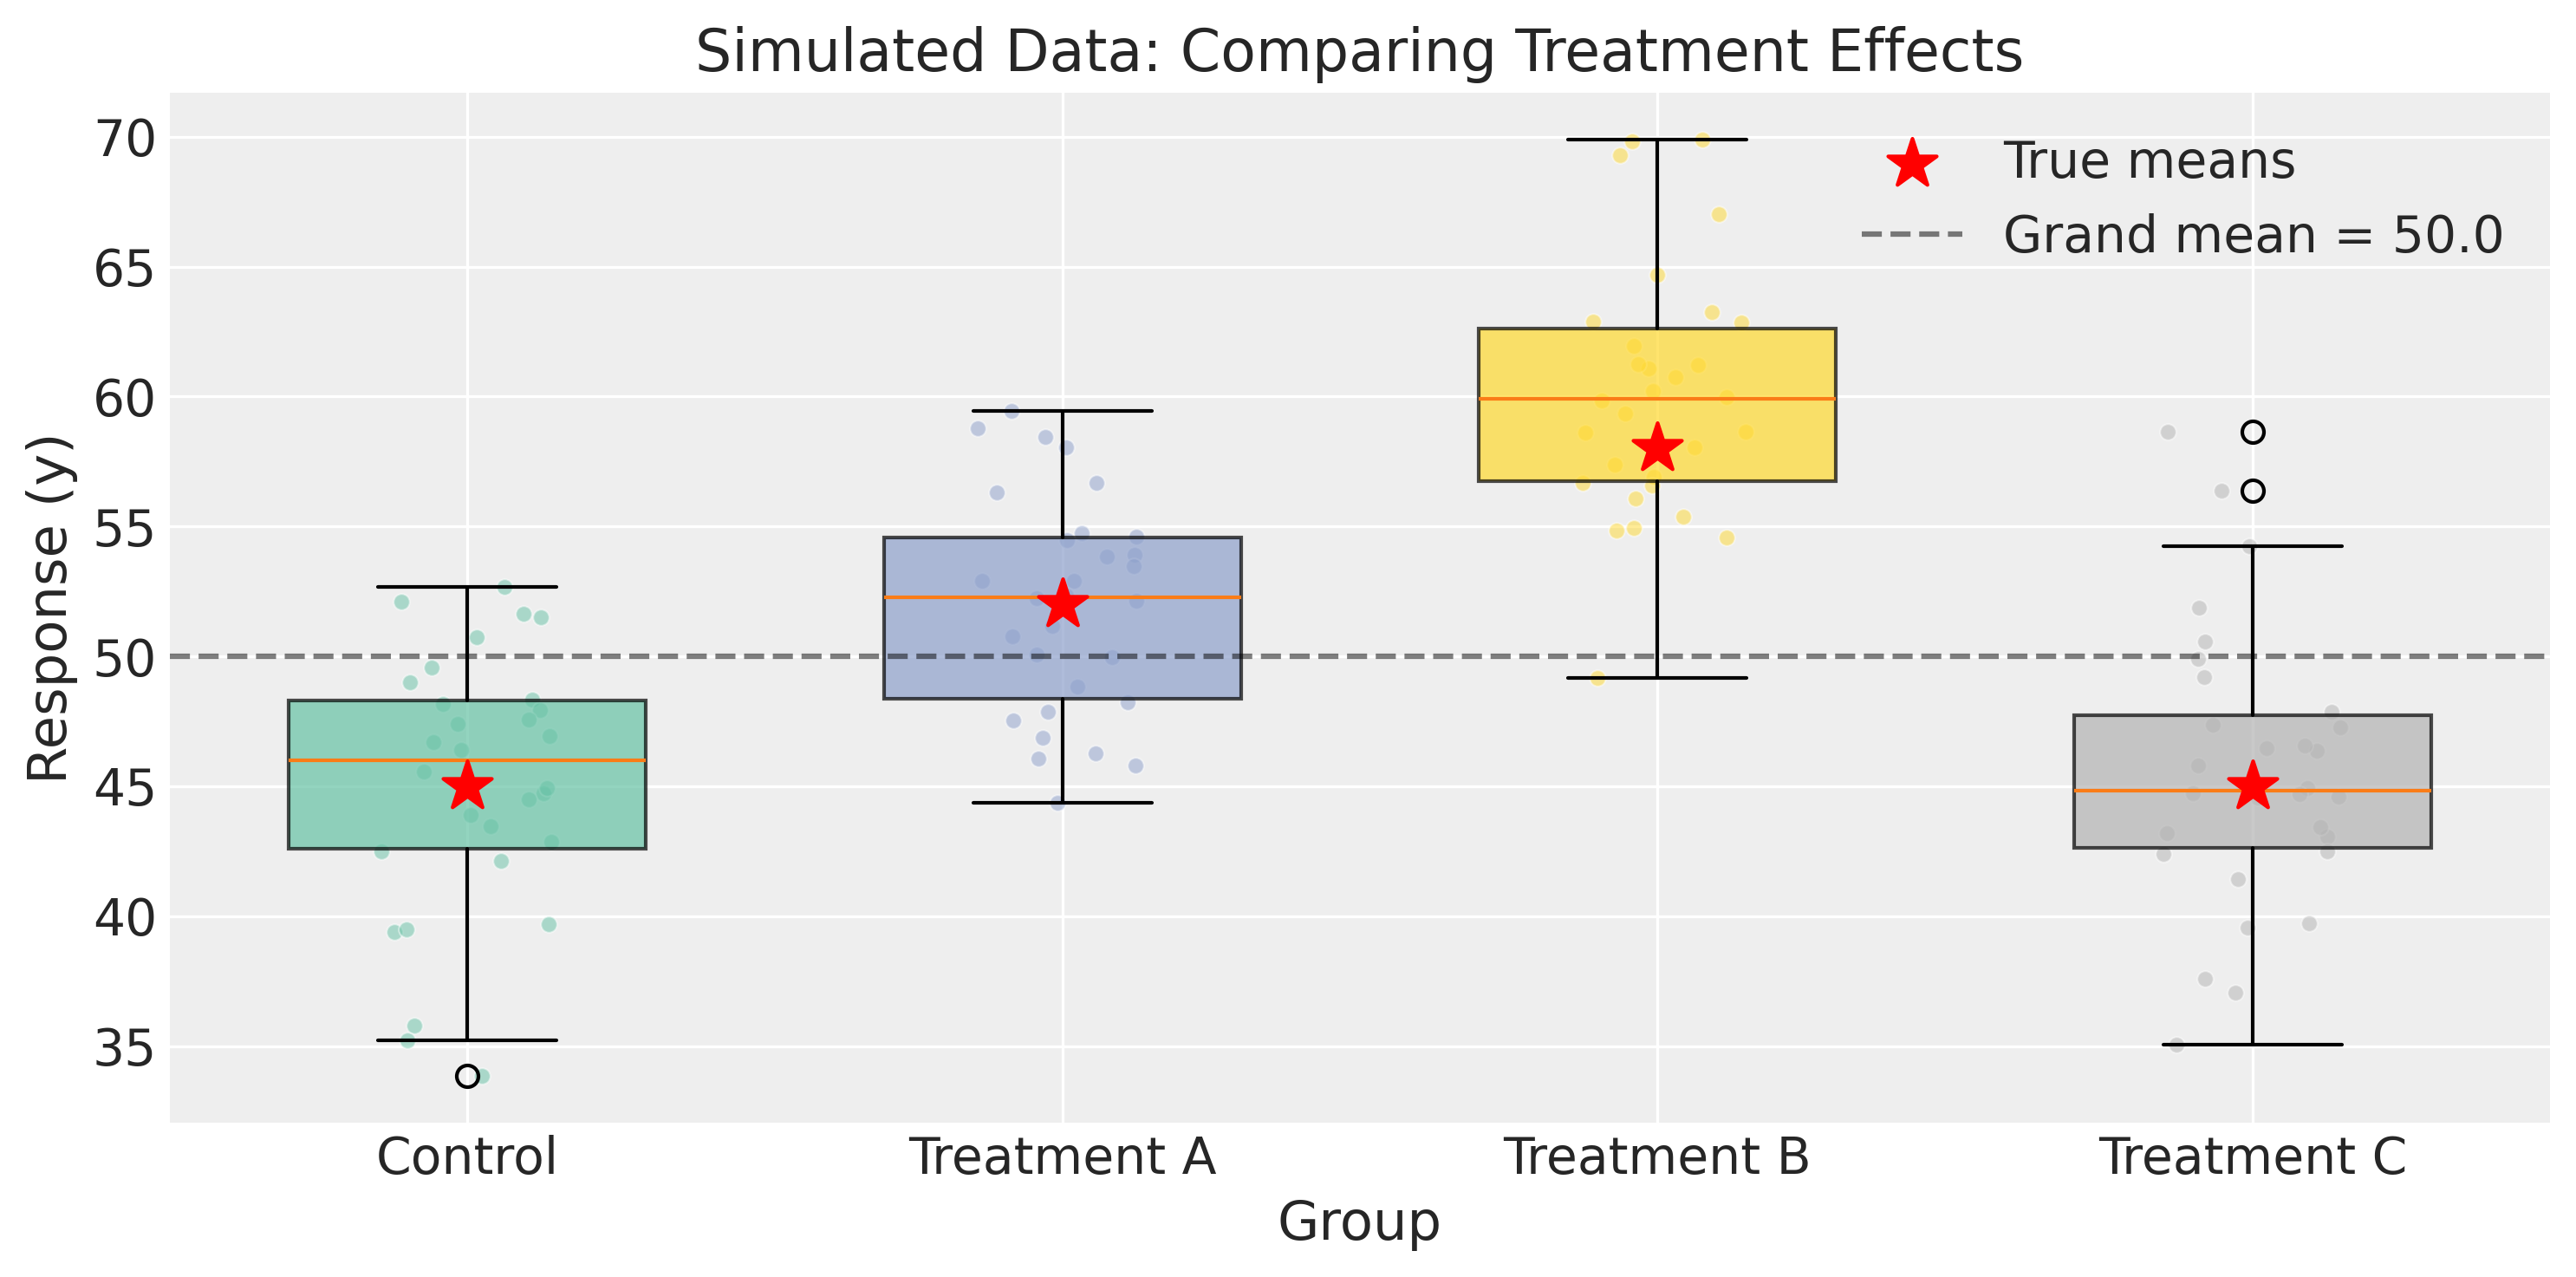

In [9]:
# Visualize the data
fig, ax = plt.subplots(figsize=(10, 5))

# Box plot
positions = np.arange(n_groups)
bp = ax.boxplot([df[df["group_idx"] == i]["y"] for i in range(n_groups)],
                positions=positions, widths=0.6, patch_artist=True)

colors = plt.cm.Set2(np.linspace(0, 1, n_groups))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual points
for i in range(n_groups):
    y_group = df[df["group_idx"] == i]["y"].values
    x_jitter = positions[i] + rng.uniform(-0.15, 0.15, size=len(y_group))
    ax.scatter(x_jitter, y_group, alpha=0.5, s=20, color=colors[i], edgecolor="white", linewidth=0.5)

# Add true group means
true_means = true_grand_mean + true_deviations
ax.scatter(positions, true_means, color="red", marker="*", s=200, zorder=5, label="True means")

# Add grand mean line
ax.axhline(true_grand_mean, color="black", linestyle="--", alpha=0.5, label=f"Grand mean = {true_grand_mean}")

ax.set_xticks(positions)
ax.set_xticklabels(group_names)
ax.set_xlabel("Group")
ax.set_ylabel("Response (y)")
ax.set_title("Simulated Data: Comparing Treatment Effects")
ax.legend()
plt.tight_layout()

### Model Specification

We'll build a model using the "intercept + deviations" parameterization:

$$
\begin{align}
y_i &\sim \text{Normal}(\mu_0 + \beta_{\text{group}[i]}, \sigma) \\
\mu_0 &\sim \text{Normal}(50, 10) \\
\beta_1, \ldots, \beta_K &\sim \text{ZeroSumNormal}(\tau) \\
\tau &\sim \text{HalfNormal}(10) \\
\sigma &\sim \text{HalfNormal}(10)
\end{align}
$$

where the `ZeroSumNormal` distribution ensures $\sum_{k=1}^{K} \beta_k = 0$.

In [10]:
coords = {
    "group": group_names,
    "obs_id": np.arange(len(df))
}

with pm.Model(coords=coords) as zsn_model:
    # Data
    group_idx = pm.Data("group_idx", df["group_idx"].values, dims="obs_id")
    
    # Priors
    mu_0 = pm.Normal("mu_0", mu=50, sigma=10)  # Grand mean
    tau = pm.HalfNormal("tau", sigma=10)  # Scale of group deviations
    sigma = pm.HalfNormal("sigma", sigma=10)  # Observation noise
    
    # Group deviations with sum-to-zero constraint
    beta = pm.ZeroSumNormal("beta", sigma=tau, dims="group")
    
    # Expected value
    mu = pm.Deterministic("mu", mu_0 + beta, dims="group")
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu_0 + beta[group_idx], sigma=sigma, 
                      observed=df["y"].values, dims="obs_id")

# Display model graph (requires graphviz binaries)
try:
    pm.model_to_graphviz(zsn_model)
except ImportError:
    print("Model graph visualization requires graphviz binaries to be installed.")

In [11]:
with zsn_model:
    idata = pm.sample(2000, tune=1000, random_seed=RANDOM_SEED, chains=4)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_0, tau, sigma, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 268 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


In [12]:
# Check convergence
az.summary(idata, var_names=["mu_0", "tau", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_0,50.701,0.451,49.870,51.554,0.004,0.005,10661.0,6246.0,1.0
tau,8.691,3.510,3.353,15.015,0.040,0.049,8269.0,6585.0,1.0
sigma,4.927,0.327,4.352,5.561,0.004,0.004,8904.0,6172.0,1.0
beta[Control],-5.478,0.778,-6.895,-4.012,0.007,0.008,11079.0,7010.0,1.0
beta[Treatment A],1.260,0.766,-0.184,2.703,0.008,0.008,9241.0,6179.0,1.0
beta[Treatment B],9.260,0.768,7.852,10.710,0.008,0.008,10224.0,6531.0,1.0
beta[Treatment C],-5.042,0.782,-6.601,-3.636,0.008,0.008,9940.0,6474.0,1.0


/tmp/ipykernel_1211/3158646252.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


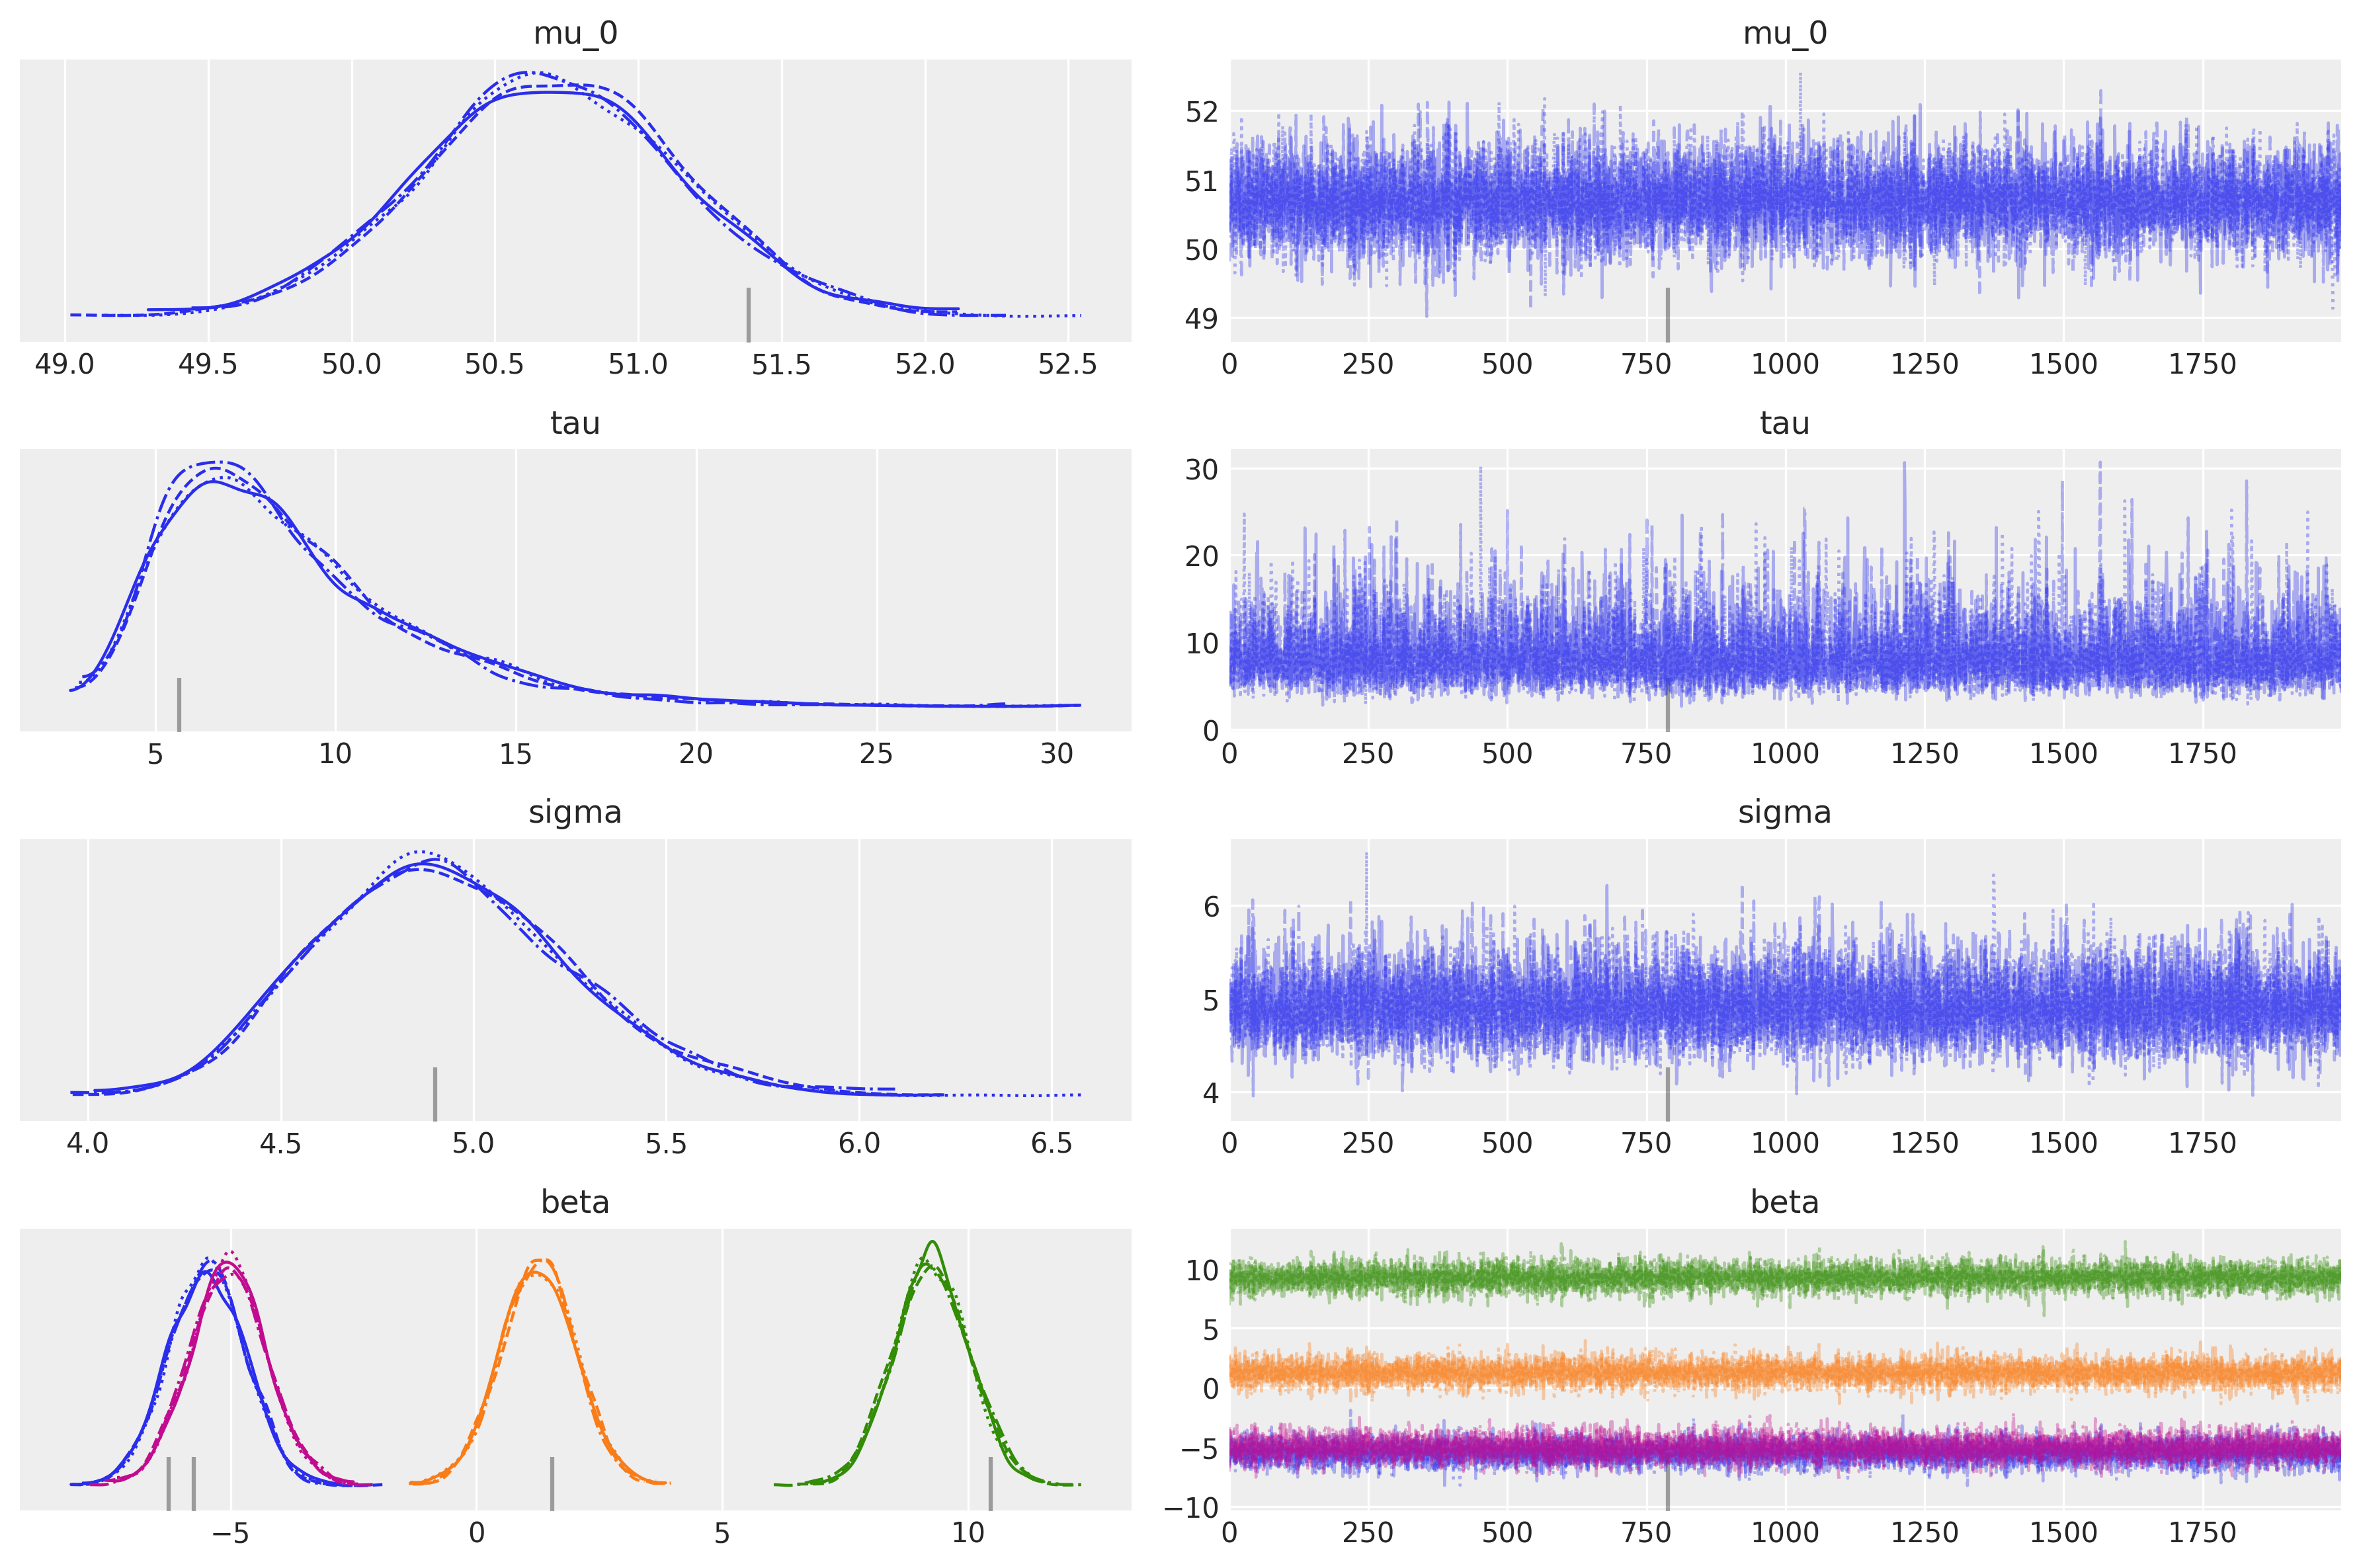

In [13]:
# Trace plots
az.plot_trace(idata, var_names=["mu_0", "tau", "sigma", "beta"])
plt.tight_layout()

### Verifying the Sum-to-Zero Constraint

In [14]:
# Extract beta samples and verify they sum to zero
beta_samples = idata.posterior["beta"].values
beta_sums = beta_samples.sum(axis=-1)  # Sum across groups

print(f"Mean of beta sums: {beta_sums.mean():.2e}")
print(f"Std of beta sums: {beta_sums.std():.2e}")
print(f"Max absolute beta sum: {np.abs(beta_sums).max():.2e}")
print("\nThe sum-to-zero constraint is satisfied!")

Mean of beta sums: 1.37e-17
Std of beta sums: 7.91e-16
Max absolute beta sum: 2.66e-15

The sum-to-zero constraint is satisfied!


### Examining Results

/tmp/ipykernel_1211/3893177161.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


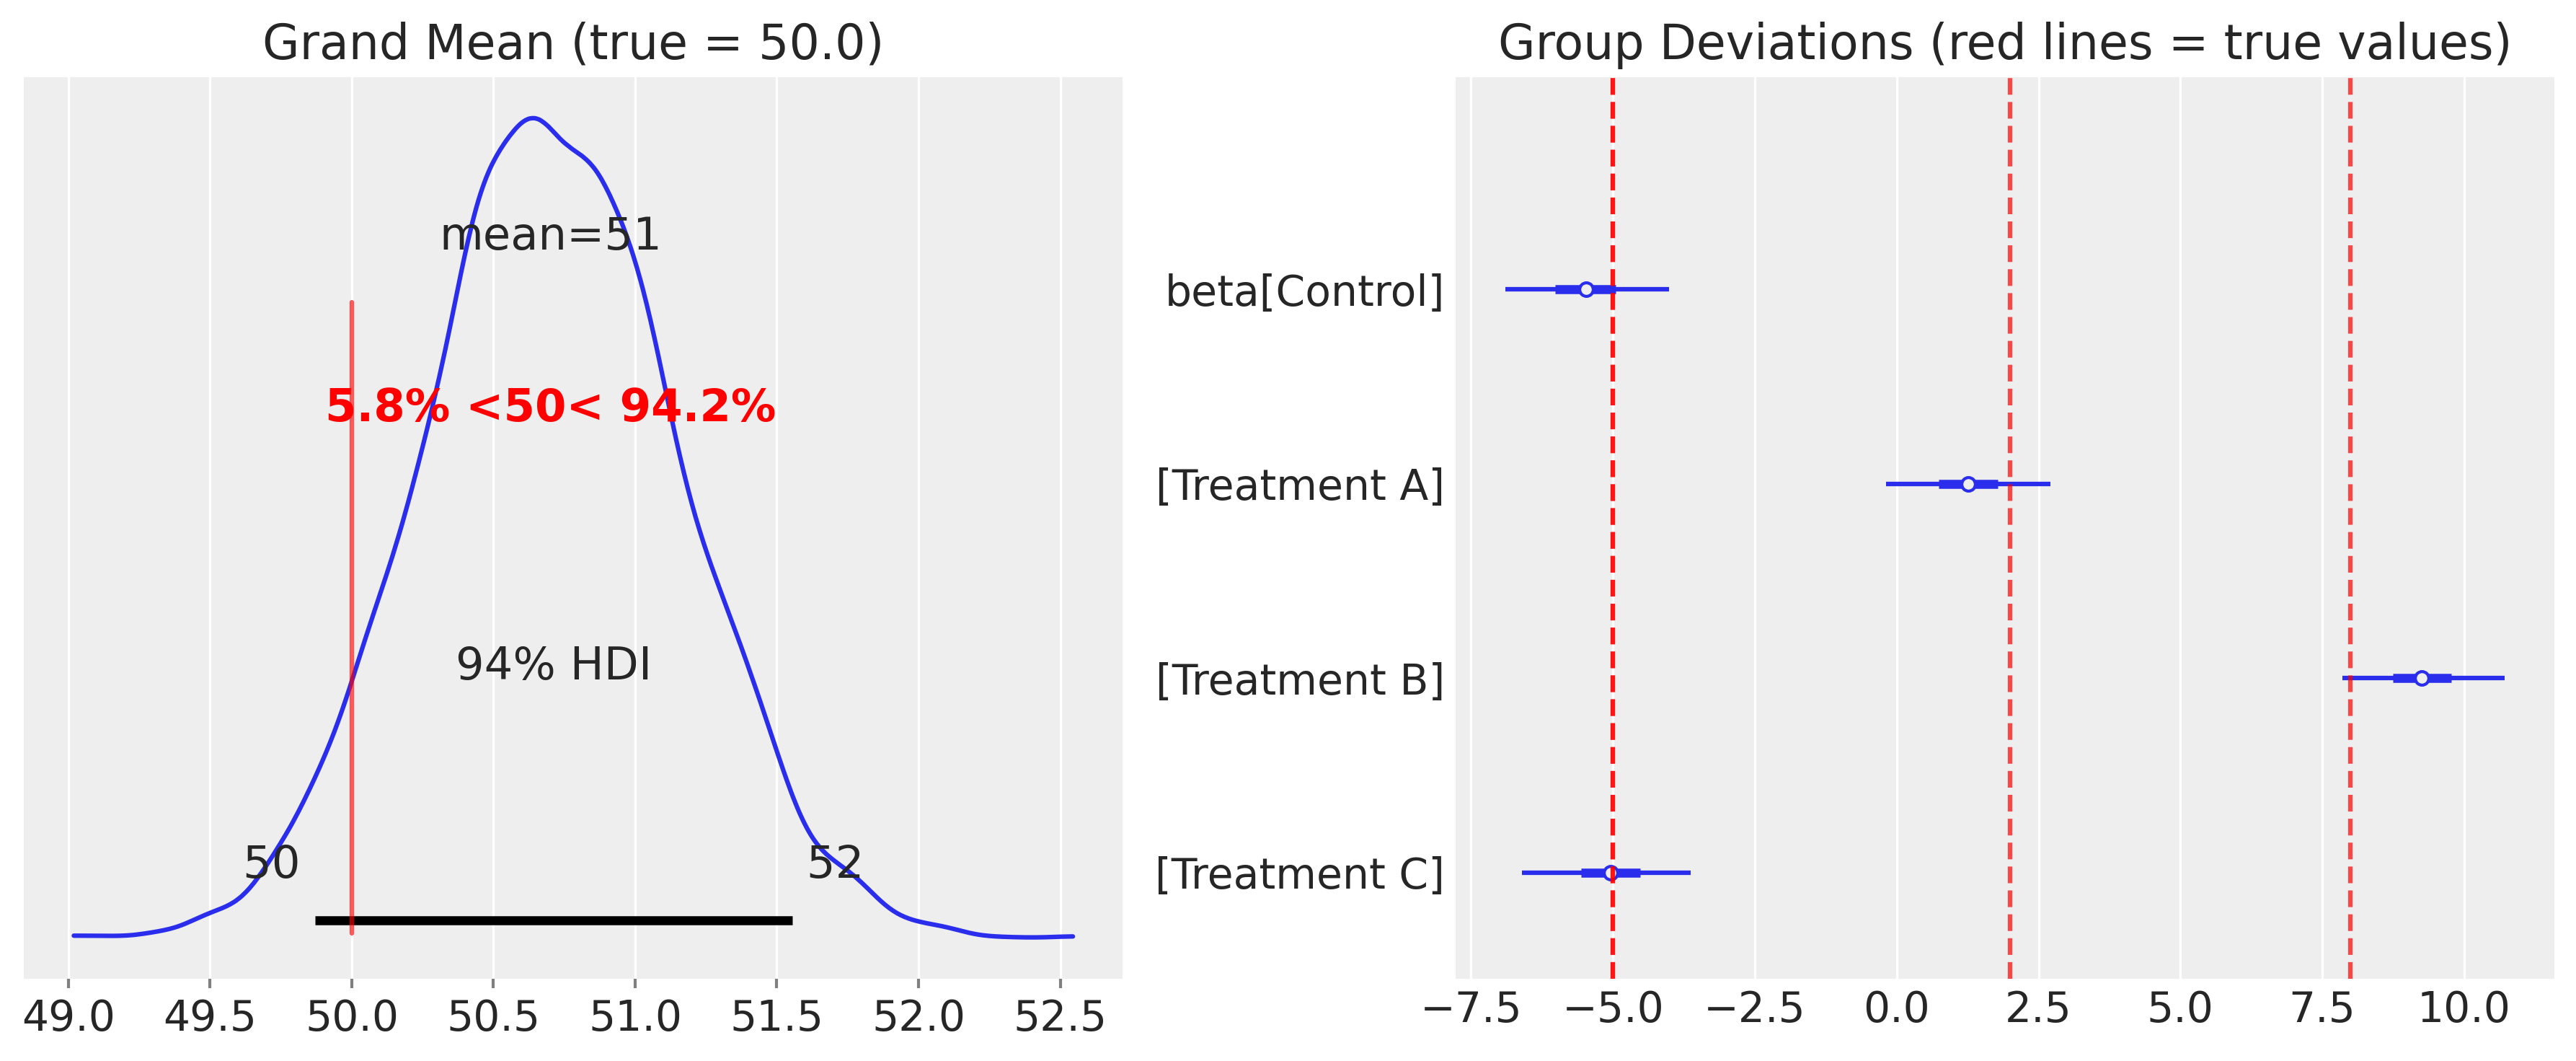

In [15]:
# Compare estimated parameters to true values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Grand mean and deviations
az.plot_posterior(idata, var_names=["mu_0"], ax=axes[0], 
                  ref_val=true_grand_mean, ref_val_color="red")
axes[0].set_title(f"Grand Mean (true = {true_grand_mean})")

# Right: Group deviations (beta)
az.plot_forest(idata, var_names=["beta"], combined=True, ax=axes[1], 
               colors="C0", figsize=(6, 4))

# Add true values
for i, true_val in enumerate(true_deviations):
    axes[1].axvline(true_val, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Group Deviations (red lines = true values)")

plt.tight_layout()

/tmp/ipykernel_1211/117606654.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


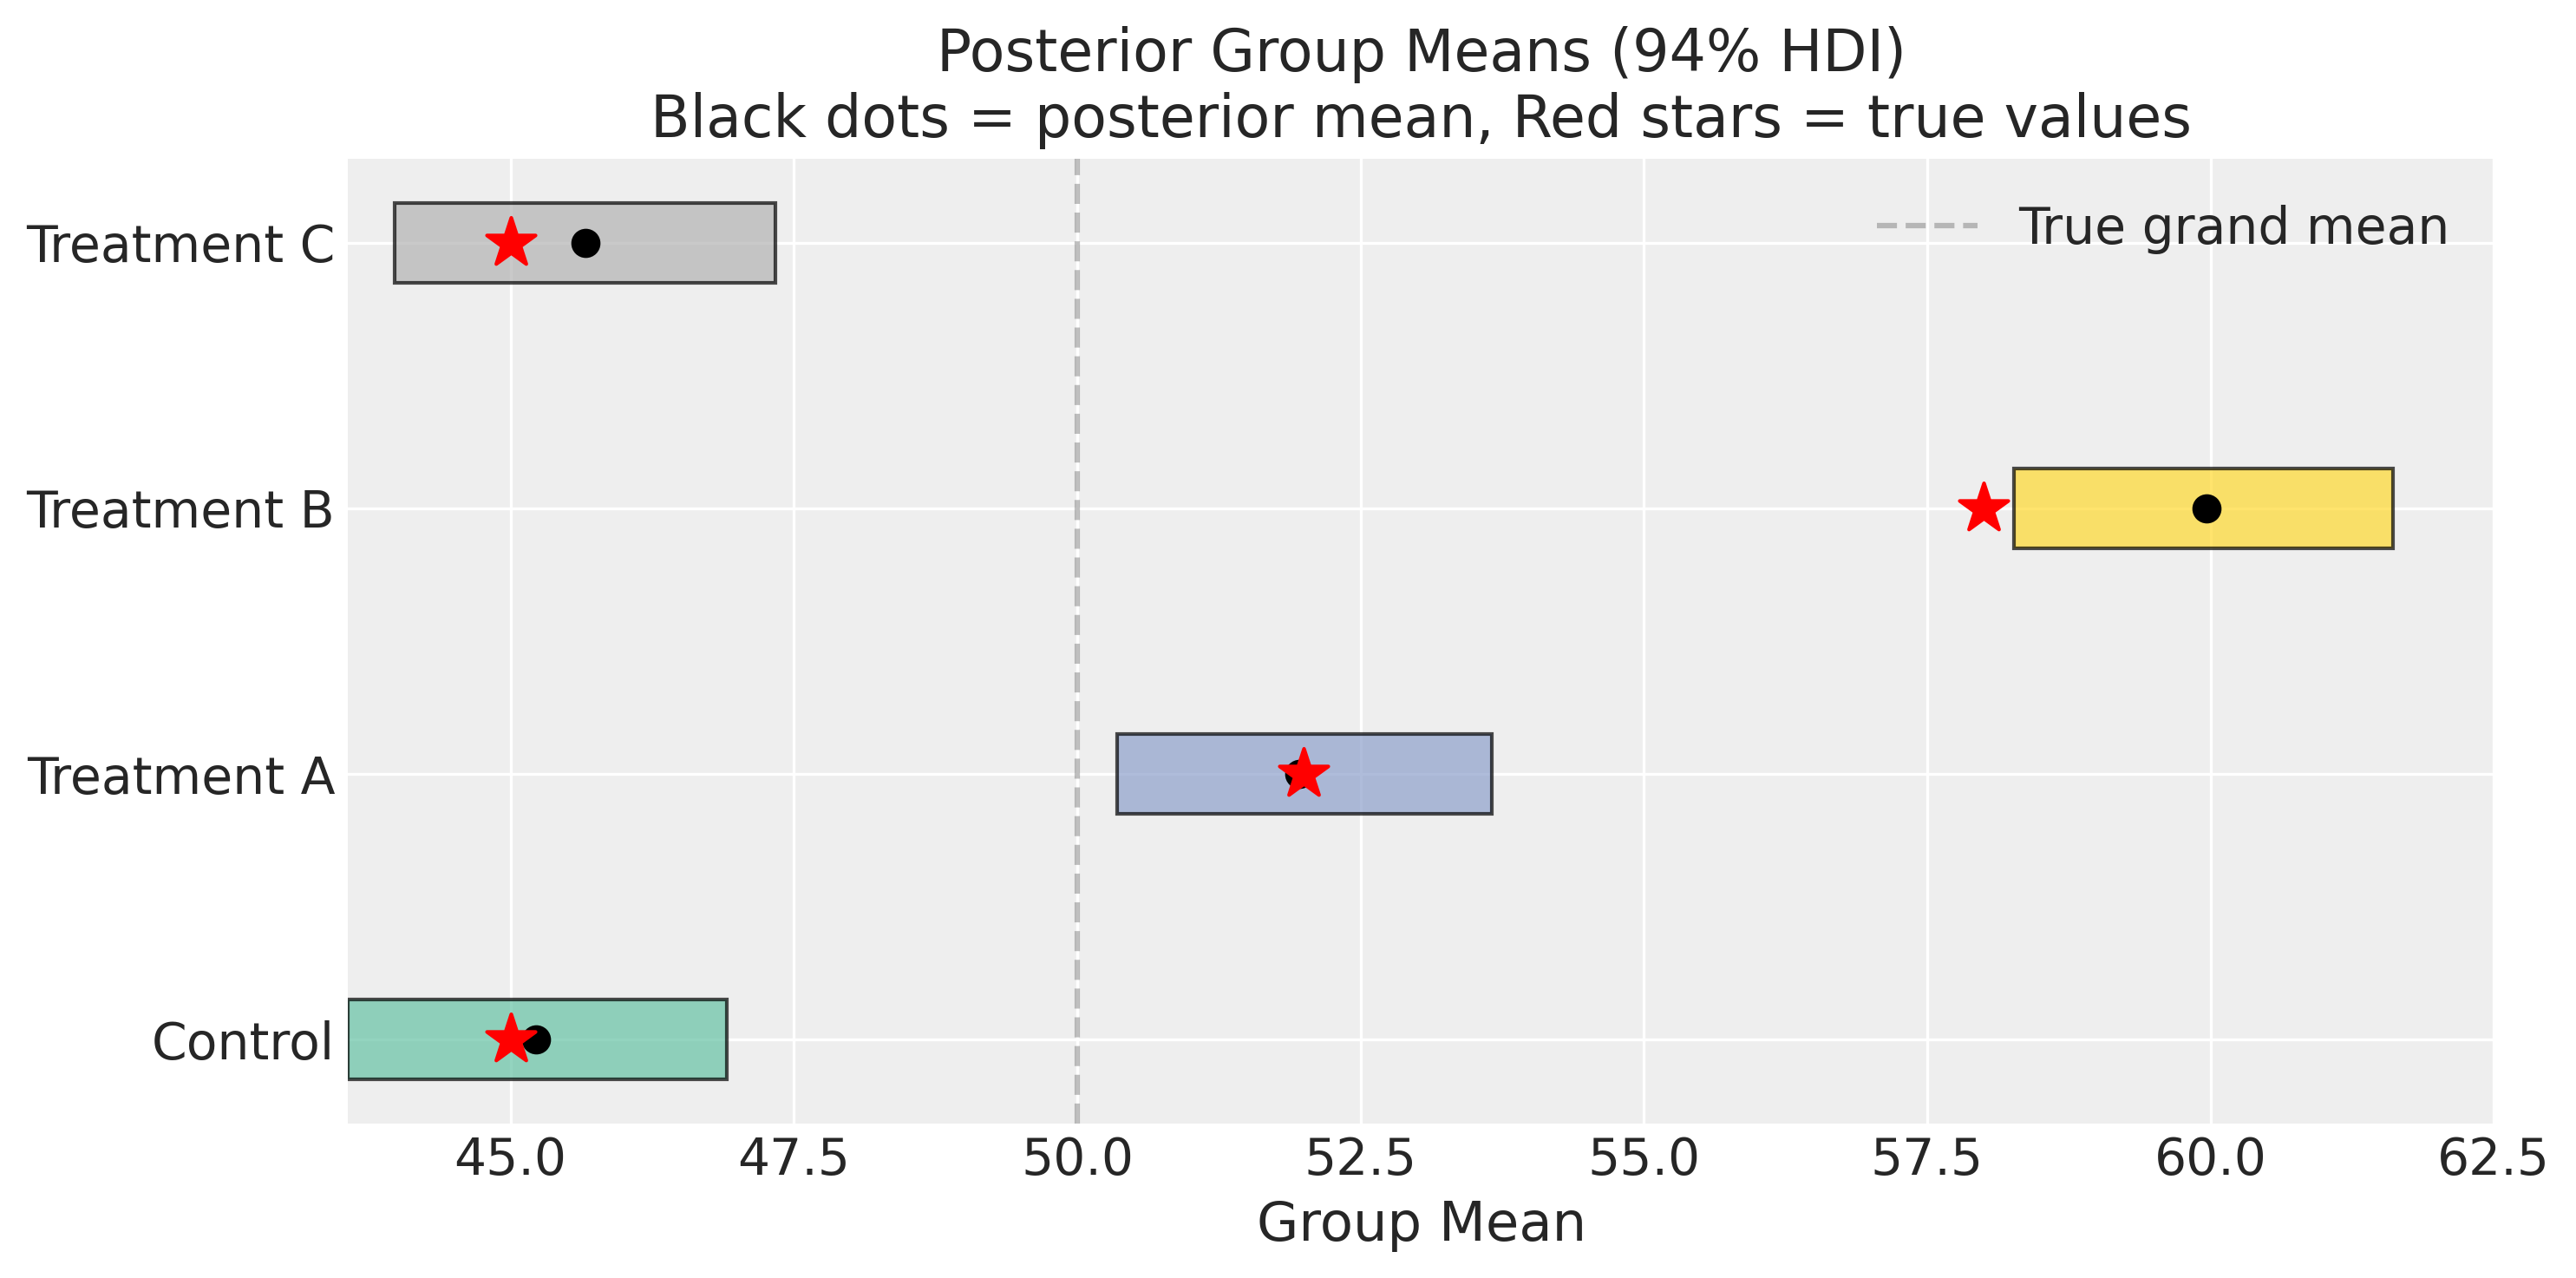

In [16]:
# Compare estimated group means to true values
fig, ax = plt.subplots(figsize=(10, 5))

# Get posterior samples for group means
mu_samples = idata.posterior["mu"].values
mu_samples_flat = mu_samples.reshape(-1, n_groups)  # Flatten chains and draws

# Compute HDI for each group
positions = np.arange(n_groups)
for i, name in enumerate(group_names):
    hdi = az.hdi(mu_samples_flat[:, i], hdi_prob=0.94)
    mean_est = mu_samples_flat[:, i].mean()
    
    # Plot HDI bar
    ax.barh(i, hdi[1] - hdi[0], left=hdi[0], height=0.3, 
            color=colors[i], alpha=0.7, edgecolor="black")
    
    # Plot posterior mean
    ax.scatter([mean_est], [i], color="black", s=50, zorder=5)
    
    # Plot true value
    true_mean = true_grand_mean + true_deviations[i]
    ax.scatter([true_mean], [i], color="red", marker="*", s=200, zorder=6)

ax.set_yticks(positions)
ax.set_yticklabels(group_names)
ax.set_xlabel("Group Mean")
ax.set_title("Posterior Group Means (94% HDI)\nBlack dots = posterior mean, Red stars = true values")
ax.axvline(true_grand_mean, color="gray", linestyle="--", alpha=0.5, label="True grand mean")
ax.legend()
plt.tight_layout()

### Computing Contrasts and Pairwise Differences

One advantage of the sum-to-zero parameterization is that pairwise contrasts are easily computed:

/tmp/ipykernel_1211/2811035823.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


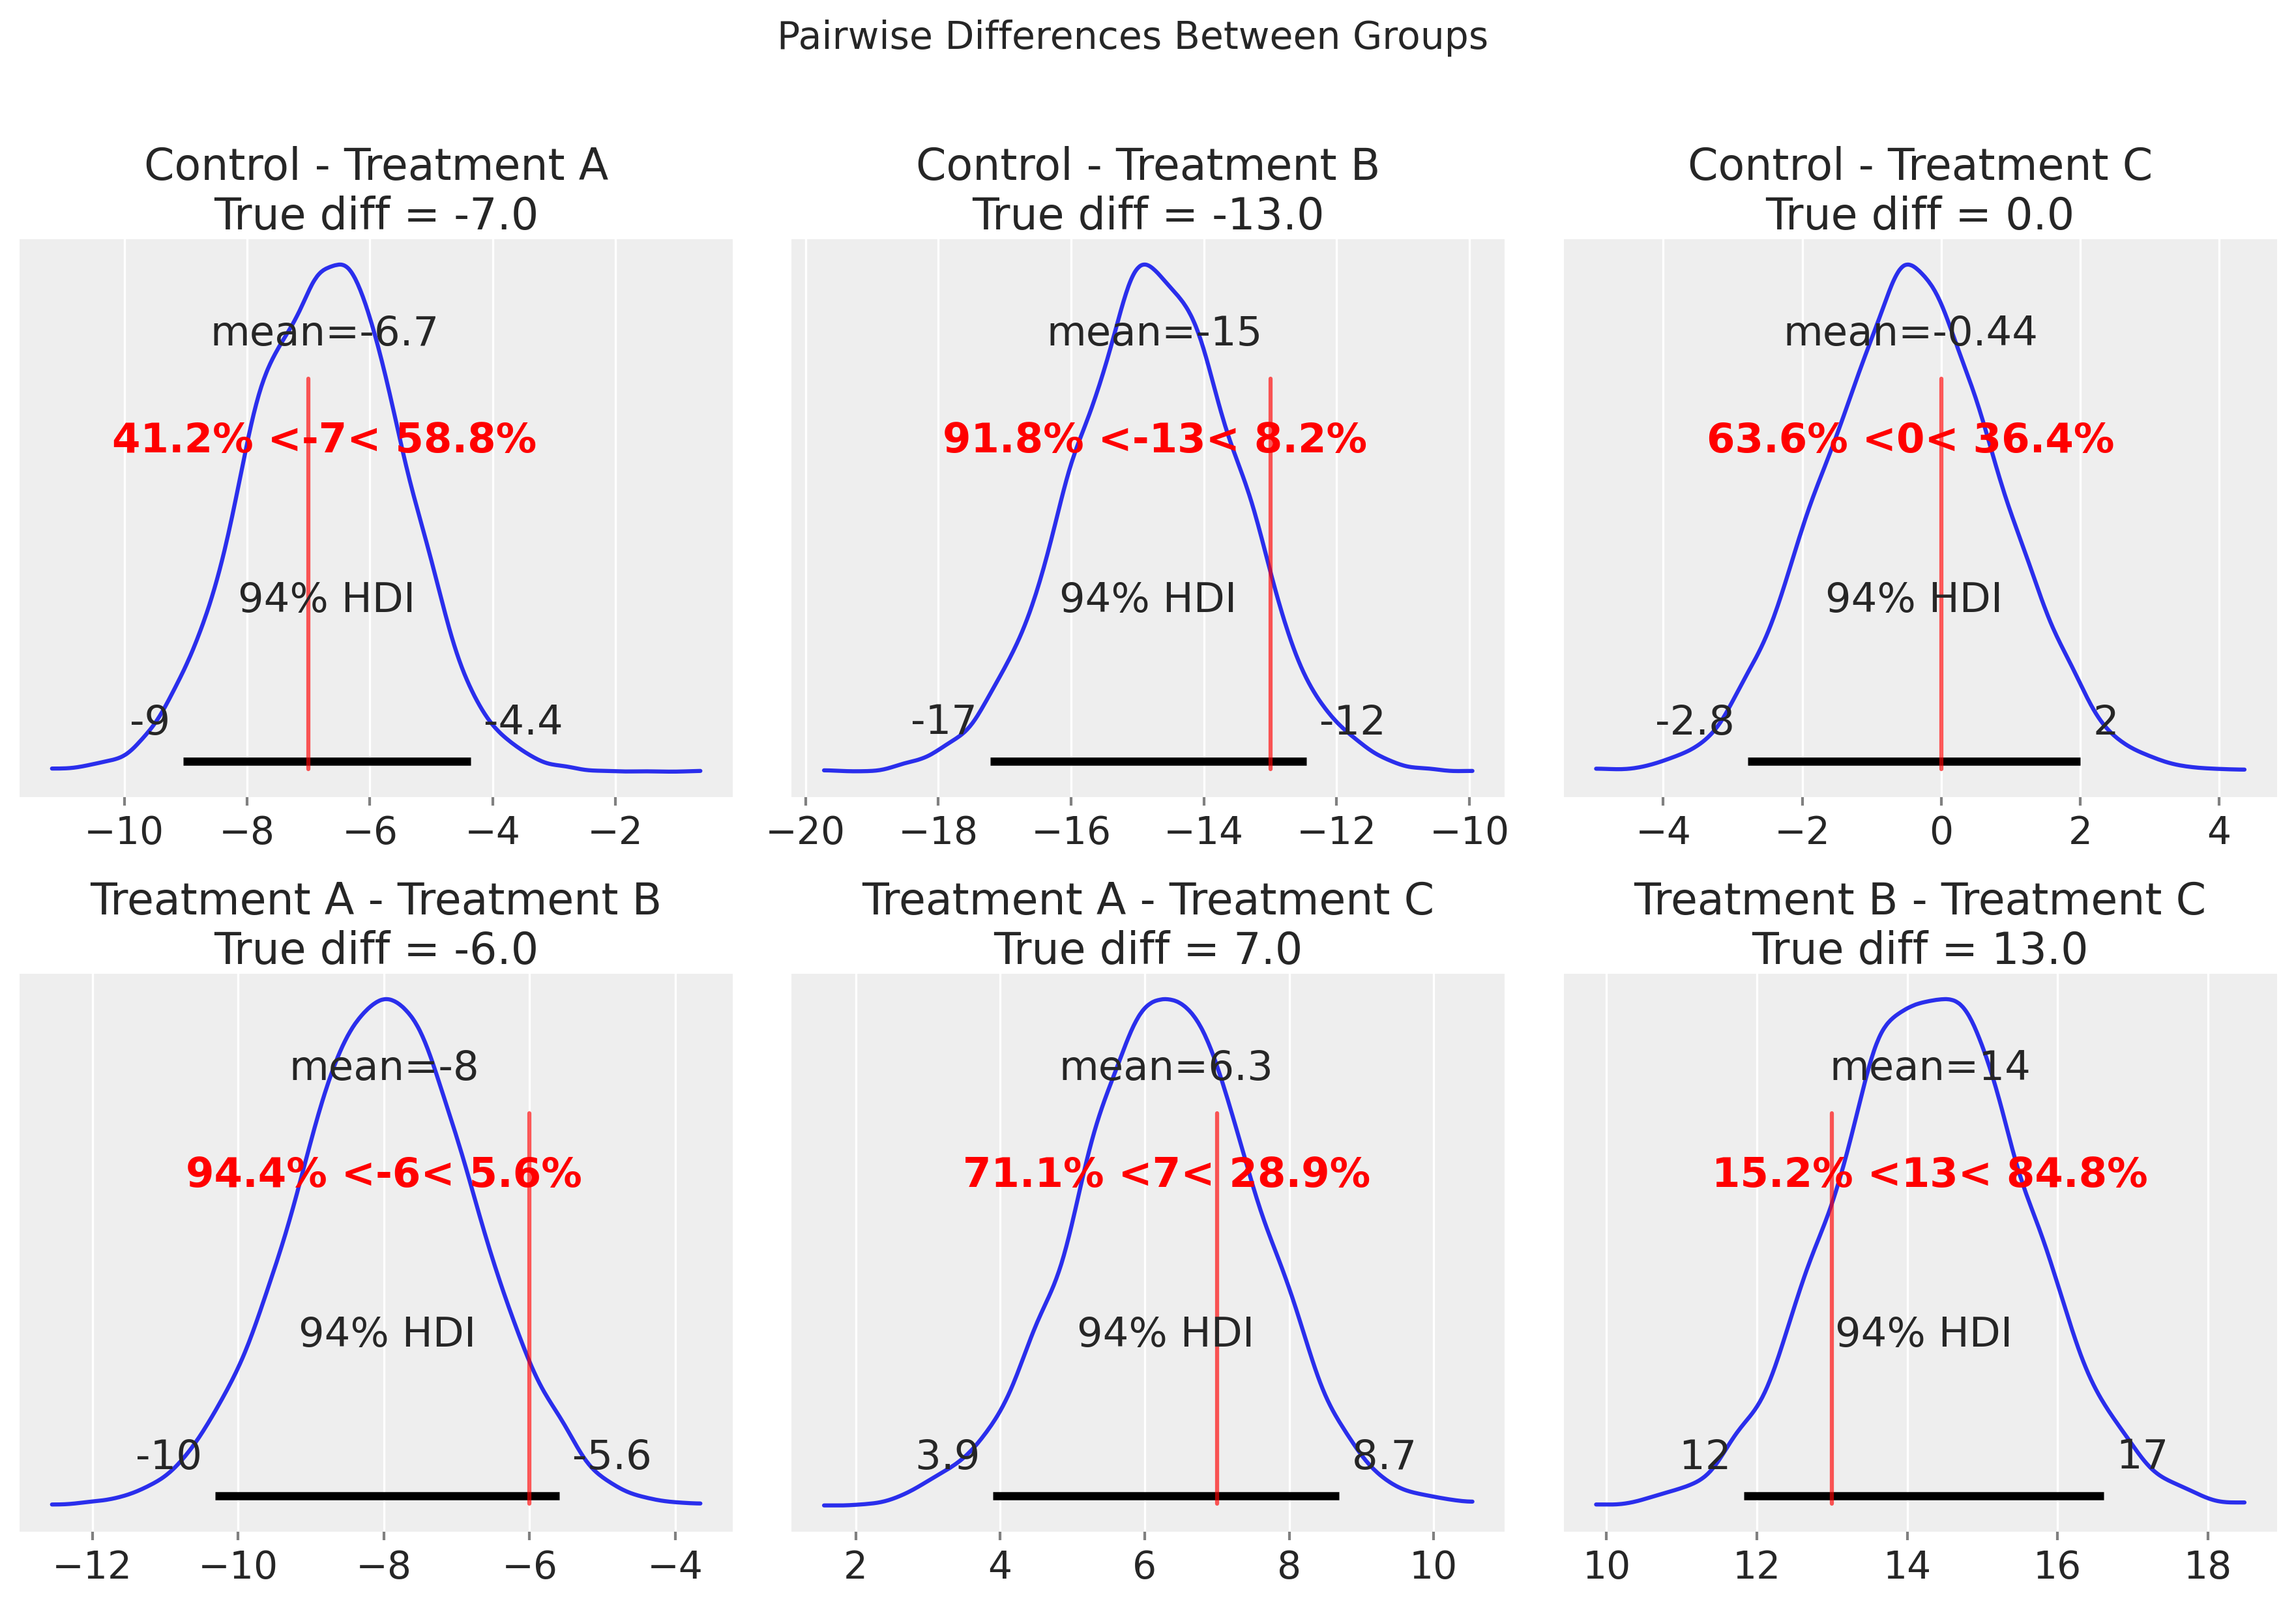

In [17]:
# Compute all pairwise differences
from itertools import combinations

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

pair_idx = 0
for i, j in combinations(range(n_groups), 2):
    diff = mu_samples_flat[:, i] - mu_samples_flat[:, j]
    true_diff = (true_grand_mean + true_deviations[i]) - (true_grand_mean + true_deviations[j])
    
    ax = axes[pair_idx]
    az.plot_posterior(diff, ax=ax, ref_val=true_diff, ref_val_color="red", 
                      point_estimate="mean")
    ax.set_title(f"{group_names[i]} - {group_names[j]}\nTrue diff = {true_diff:.1f}")
    pair_idx += 1

plt.suptitle("Pairwise Differences Between Groups", fontsize=14, y=1.02)
plt.tight_layout()

## Comparison: ZeroSumNormal vs Reference Coding

Let's compare our `ZeroSumNormal` model to a traditional reference-coded model:

In [18]:
# Reference coding model (using Control as reference)
with pm.Model(coords={"treatment": group_names[1:], "obs_id": np.arange(len(df))}) as ref_model:
    # Data
    group_idx = pm.Data("group_idx", df["group_idx"].values, dims="obs_id")
    
    # Priors
    alpha = pm.Normal("alpha", mu=50, sigma=10)  # Mean of reference group (Control)
    beta_ref = pm.Normal("beta_ref", mu=0, sigma=10, dims="treatment")  # Differences from reference
    sigma = pm.HalfNormal("sigma", sigma=10)
    
    # Build expected value
    # beta_full[0] = 0 (reference), beta_full[1:] = beta_ref
    beta_full = pm.math.concatenate([[0], beta_ref])
    mu = alpha + beta_full[group_idx]
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=df["y"].values, dims="obs_id")

with ref_model:
    idata_ref = pm.sample(2000, tune=1000, random_seed=RANDOM_SEED, chains=4)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [alpha, beta_ref, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 358 seconds.


/tmp/ipykernel_1211/1851114581.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


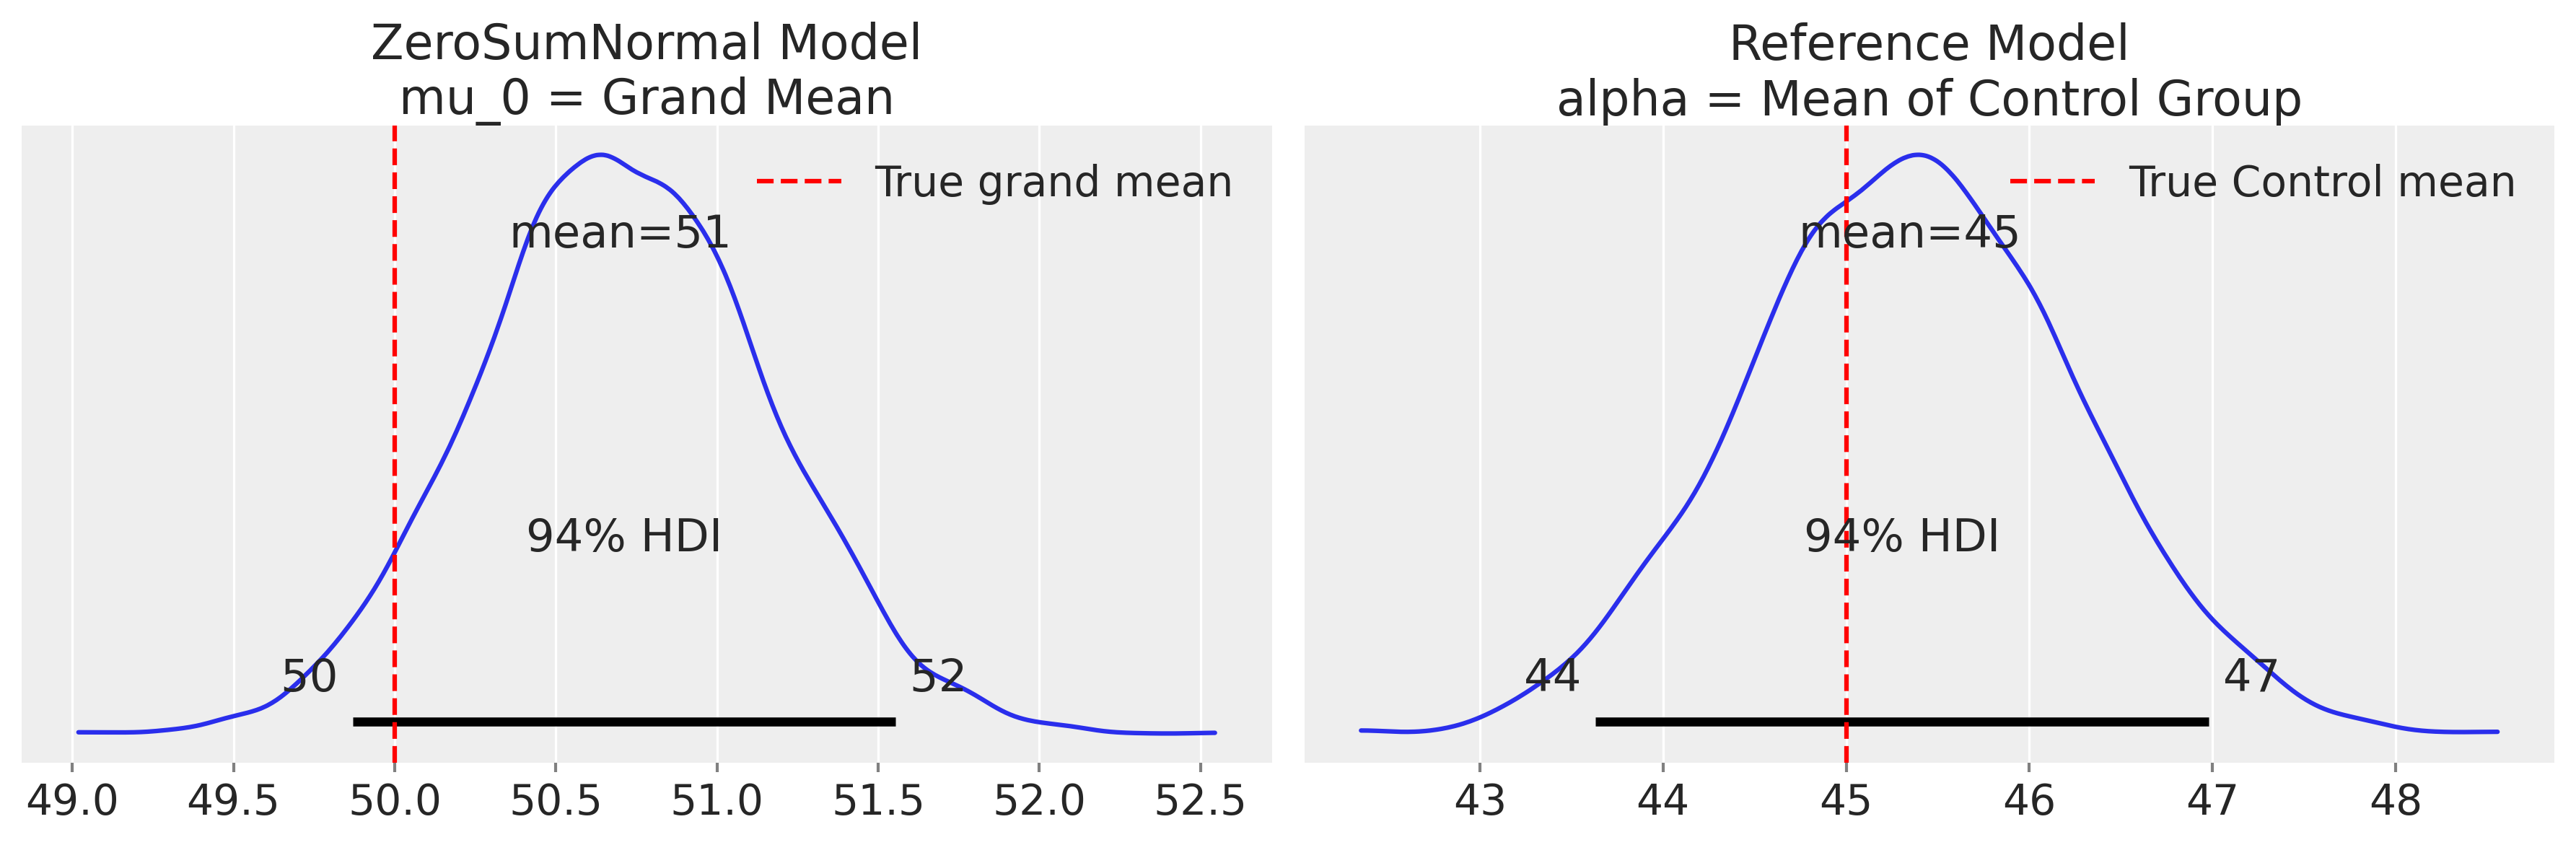

In [19]:
# Compare interpretations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ZeroSumNormal model
ax = axes[0]
az.plot_posterior(idata, var_names=["mu_0"], ax=ax)
ax.axvline(true_grand_mean, color="red", linestyle="--", label="True grand mean")
ax.set_title("ZeroSumNormal Model\nmu_0 = Grand Mean")
ax.legend()

# Reference model
ax = axes[1]
az.plot_posterior(idata_ref, var_names=["alpha"], ax=ax)
true_control_mean = true_grand_mean + true_deviations[0]
ax.axvline(true_control_mean, color="red", linestyle="--", label="True Control mean")
ax.set_title("Reference Model\nalpha = Mean of Control Group")
ax.legend()

plt.tight_layout()

### Key Differences in Interpretation

| Aspect | ZeroSumNormal | Reference Coding |
|--------|---------------|------------------|
| **Intercept meaning** | Grand mean | Reference group mean |
| **Group effects** | Deviations from grand mean | Differences from reference |
| **Symmetry** | All groups treated equally | Reference group treated specially |
| **Prior specification** | Single $\tau$ controls all effects | Independent priors on each contrast |
| **Sum constraint** | Automatic | Not applicable |

## Advanced Usage: Multiple Zero-Sum Axes

`ZeroSumNormal` can constrain multiple axes to sum to zero. This is useful for multi-way ANOVA-style models:

In [20]:
# Example: Two-way ANOVA with regions and time periods
regions = ["North", "South", "East", "West"]
periods = ["Q1", "Q2", "Q3", "Q4"]

coords_2way = {
    "region": regions,
    "period": periods
}

with pm.Model(coords=coords_2way) as model_2way:
    # Main effect for regions (sums to zero across regions)
    region_effect = pm.ZeroSumNormal("region_effect", sigma=5, dims="region")
    
    # Main effect for periods (sums to zero across periods)
    period_effect = pm.ZeroSumNormal("period_effect", sigma=5, dims="period")
    
    # Interaction effect (sums to zero along BOTH axes!)
    interaction = pm.ZeroSumNormal("interaction", sigma=2, 
                                    dims=("region", "period"),
                                    n_zerosum_axes=2)
    
    # Draw prior samples
    prior = pm.draw([region_effect, period_effect, interaction], draws=5000, 
                   random_seed=RANDOM_SEED)

print("Region effect shape:", prior[0].shape)
print("Region effect sum (should be ~0):", prior[0].sum(axis=-1).mean())
print()
print("Period effect shape:", prior[1].shape)
print("Period effect sum (should be ~0):", prior[1].sum(axis=-1).mean())
print()
print("Interaction shape:", prior[2].shape)
print("Interaction sum over regions (should be ~0):", prior[2].sum(axis=-2).mean())
print("Interaction sum over periods (should be ~0):", prior[2].sum(axis=-1).mean())

Region effect shape: (5000, 4)
Region effect sum (should be ~0): -5.470623953840459e-18

Period effect shape: (5000, 4)
Period effect sum (should be ~0): 9.31060784026272e-18

Interaction shape: (5000, 4, 4)
Interaction sum over regions (should be ~0): 4.550873566877556e-18
Interaction sum over periods (should be ~0): 4.245909179800833e-18


## Summary

In this notebook, we explored:

1. **Why identifiability matters**: Design matrices with categorical predictors can be rank-deficient, leading to non-unique parameter estimates.

2. **Contrast coding schemes**: Reference coding and sum-to-zero coding are common solutions, each with different interpretations.

3. **ZeroSumNormal distribution**: PyMC's `ZeroSumNormal` provides an elegant, symmetric solution that:
   - Automatically enforces sum-to-zero constraints
   - Treats all groups symmetrically
   - Has intuitive prior specification
   - Supports multi-dimensional constraints

4. **Practical application**: We demonstrated how to use `ZeroSumNormal` for comparing group means, with the intercept representing the grand mean and group effects representing deviations.

The `ZeroSumNormal` distribution is particularly valuable when:
- You want the intercept to represent the grand mean
- All groups should be treated symmetrically
- You need hierarchical shrinkage on the group effects
- You have multi-way factorial designs with interaction terms

## Authors

- Original notebook concept by [Benjamin T. Vincent](https://github.com/drbenvincent) and [Adrian Seyboldt](https://github.com/aseyboldt) (2021)
- Rewritten for PyMC v5 by Claude in February 2026, based on the [original PR #210](https://github.com/pymc-devs/pymc-examples/pull/210)

## References

- [PyMC ZeroSumNormal Documentation](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.ZeroSumNormal.html)
- Schad, D. J., Vasishth, S., Hohenstein, S., & Kliegl, R. (2020). How to capitalize on a priori contrasts in linear (mixed) models: A tutorial. Journal of Memory and Language, 110, 104038.

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [21]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor

Last updated: Fri, 13 Feb 2026

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.10.0

pytensor: 2.37.0

arviz     : 0.23.4
matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 3.0.0
pymc      : 5.27.1
scipy     : 1.17.0

Watermark: 2.6.0



:::{include} ../page_footer.md
:::